# Notebook 04 — Gradient Boosting Survival Analysis

## Overview
Gradient boosting survival model using scikit-survival's 
`GradientBoostingSurvivalAnalysis` — a tree-based ensemble method that extends 
Cox proportional hazards to capture non-linear feature interactions.

## Objective
Compare predictive performance of gradient boosting against the Cox PH baseline 
(C-index = 0.707, Notebook 01) using the same clinical and molecular features. 
Evaluate feature importance and assess whether non-linear methods improve 
survival discrimination in TCGA LUAD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
FIG_DIR = 'figures/'

print("Imports OK")

Imports OK


In [3]:
# --- Load data ---
clinical = pd.read_csv('../data/processed/clinical_clean.csv')

# Drop missing OS first
clinical = clinical.dropna(subset=['OS_STATUS', 'OS_MONTHS'])

# Fix OS_STATUS encoding
clinical['OS_STATUS'] = clinical['OS_STATUS'].str.startswith('1').astype(int)

# Encode categoricals
clinical['STAGE_NUM'] = clinical['STAGE_SIMPLE'].map({'I':1,'II':2,'III':3,'IV':4})
clinical['FEMALE'] = (clinical['SEX'] == 'Female').astype(int)

ML_FEATURES = [
    'AGE', 'STAGE_NUM', 'FEMALE',
    'TMB_NONSYNONYMOUS', 'ANEUPLOIDY_SCORE',
    'TP53_MUT', 'KRAS_MUT', 'STK11_MUT', 'KEAP1_MUT', 'EGFR_MUT'
]

df = clinical[ML_FEATURES + ['OS_STATUS', 'OS_MONTHS']].dropna()

print(f"Cohort: n={len(df)}, events={df['OS_STATUS'].sum()}, event rate={df['OS_STATUS'].mean():.1%}")

y = Surv.from_dataframe('OS_STATUS', 'OS_MONTHS', df)
X = df[ML_FEATURES]

print(f"X shape: {X.shape}")

Cohort: n=485, events=172, event rate=35.5%
X shape: (485, 10)


In [4]:
# --- Train/test split ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Train: n={len(X_train)}, events={y_train['OS_STATUS'].sum()}")
print(f"Test:  n={len(X_test)}, events={y_test['OS_STATUS'].sum()}")

Train: n=363, events=129
Test:  n=122, events=43


In [5]:
# --- Fit Cox PH baseline (sksurv) ---
cox = CoxPHSurvivalAnalysis(alpha=0.1)
cox.fit(X_train, y_train)

cox_cindex = concordance_index_censored(
    y_test['OS_STATUS'], y_test['OS_MONTHS'], cox.predict(X_test)
)[0]

print(f"Cox PH C-index (test): {cox_cindex:.3f}")

# --- Fit Gradient Boosting Survival ---
gbs = GradientBoostingSurvivalAnalysis(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)
gbs.fit(X_train, y_train)

gbs_cindex = concordance_index_censored(
    y_test['OS_STATUS'], y_test['OS_MONTHS'], gbs.predict(X_test)
)[0]

print(f"GBS C-index (test):    {gbs_cindex:.3f}")

Cox PH C-index (test): 0.767
GBS C-index (test):    0.711


In [6]:
# --- 5-fold cross-validation ---
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cox_scores = []
gbs_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # Cox
    cox_cv = CoxPHSurvivalAnalysis(alpha=0.1)
    cox_cv.fit(X_tr, y_tr)
    c = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_MONTHS'], cox_cv.predict(X_val)
    )[0]
    cox_scores.append(c)
    
    # GBS
    gbs_cv = GradientBoostingSurvivalAnalysis(
        n_estimators=100, learning_rate=0.1,
        max_depth=3, random_state=RANDOM_STATE
    )
    gbs_cv.fit(X_tr, y_tr)
    c = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_MONTHS'], gbs_cv.predict(X_val)
    )[0]
    gbs_scores.append(c)

print(f"Cox CV C-index: {np.mean(cox_scores):.3f} ± {np.std(cox_scores):.3f}")
print(f"GBS CV C-index: {np.mean(gbs_scores):.3f} ± {np.std(gbs_scores):.3f}")

Cox CV C-index: 0.682 ± 0.056
GBS CV C-index: 0.646 ± 0.050


## 3. Model Comparison: Cox PH vs Gradient Boosting Survival

| Model | C-index (test) | C-index (5-fold CV) |
|---|---|---|
| Cox PH | 0.767 | 0.682 ± 0.056 |
| Gradient Boosting Survival | 0.711 | 0.646 ± 0.050 |

Cox PH outperforms Gradient Boosting Survival both on the held-out test set
and in cross-validation. This is consistent with a well-established pattern
in survival analysis with small clinical datasets: linear models generalize
better when sample size is limited relative to feature complexity.

Gradient boosting requires sufficient data to learn non-linear interactions
and avoid overfitting — with n=485 and 10 features, the signal-to-noise ratio
favors the simpler Cox model. This pattern was also observed in Notebook 01,
where Logistic Regression outperformed Random Forest and Gradient Boosting
for 2-year mortality prediction.

**Implication for RWE practice:** In large EHR datasets (n=10,000+),
gradient boosting typically achieves meaningful gains over Cox —
the TCGA result reflects dataset size constraints, not a fundamental limitation
of the method.

## 4. Feature Importance

In [9]:
# --- Feature importance ---
result = permutation_importance(
    gbs, X_test, y_test,
    n_repeats=100,
    random_state=RANDOM_STATE
)

importance_df = pd.DataFrame({
    'feature': ML_FEATURES,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print(importance_df.round(4).to_string(index=False))

          feature  importance    std
        STAGE_NUM      0.1665 0.0458
              AGE      0.0327 0.0186
 ANEUPLOIDY_SCORE      0.0212 0.0100
         TP53_MUT      0.0151 0.0062
         KRAS_MUT      0.0055 0.0104
TMB_NONSYNONYMOUS      0.0025 0.0161
        STK11_MUT      0.0019 0.0080
        KEAP1_MUT     -0.0004 0.0014
           FEMALE     -0.0005 0.0051
         EGFR_MUT     -0.0020 0.0019


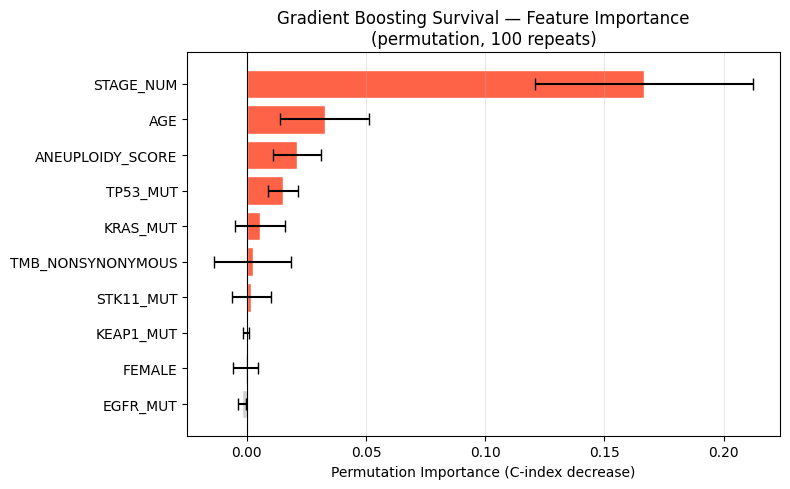

Saved.


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

importance_sorted = importance_df.sort_values('importance', ascending=True)

colors = ['tomato' if x > 0 else 'lightgray' for x in importance_sorted['importance']]

ax.barh(importance_sorted['feature'], importance_sorted['importance'],
        xerr=importance_sorted['std'], color=colors,
        capsize=4, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Permutation Importance (C-index decrease)')
ax.set_title('Gradient Boosting Survival — Feature Importance\n(permutation, 100 repeats)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig24_gbs_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

### Feature Importance — Gradient Boosting Survival
(permutation importance, 100 repeats on test set)

Stage is the overwhelmingly dominant predictor (importance=0.17), consistent
with all previous analyses in this project. Age and aneuploidy score are the
next most informative features.

Notably, STK11 — the strongest prognostic factor in the multivariable Cox model
(HR=1.67, p=0.01, Notebook 01) — shows near-zero permutation importance here.
This reflects a fundamental difference between the two methods: Cox measures
the independent effect of a feature after controlling for all others, while
permutation importance measures marginal predictive contribution. STK11 is
prognostically important but adds little discriminative power beyond what
stage and age already capture.

KEAP1, FEMALE, and EGFR show negative importance values — within noise of zero,
indicating no independent predictive contribution in this dataset.

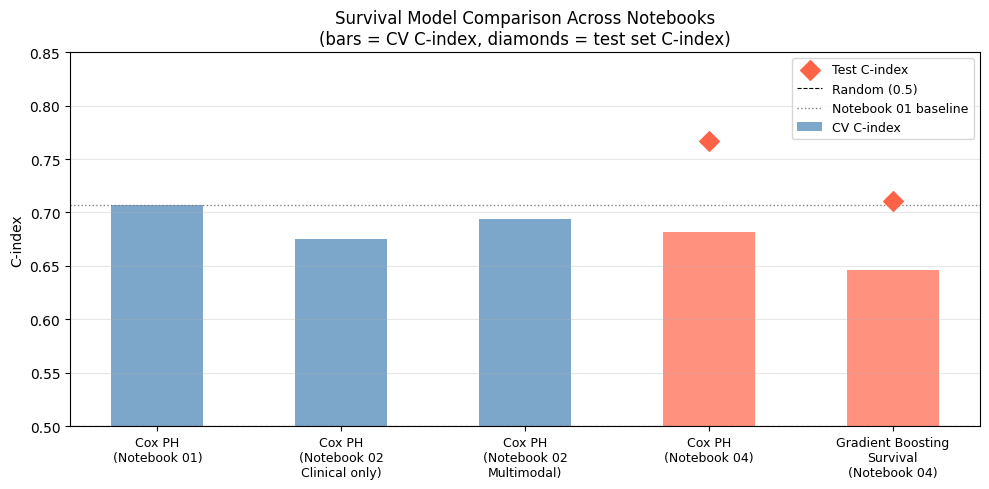

Saved.


In [11]:
# --- Final model comparison across all notebooks ---
fig, ax = plt.subplots(figsize=(10, 5))

models = [
    'Cox PH\n(Notebook 01)',
    'Cox PH\n(Notebook 02\nClinical only)',
    'Cox PH\n(Notebook 02\nMultimodal)',
    'Cox PH\n(Notebook 04)',
    'Gradient Boosting\nSurvival\n(Notebook 04)',
]

cindex_cv = [0.707, 0.675, 0.694, 0.682, 0.646]
cindex_test = [None, None, None, 0.767, 0.711]
colors = ['steelblue', 'steelblue', 'steelblue', 'tomato', 'tomato']

x_pos = range(len(models))

bars = ax.bar(x_pos, cindex_cv, color=colors, alpha=0.7, width=0.5, label='CV C-index')

# Add test set dots where available
for i, ct in enumerate(cindex_test):
    if ct is not None:
        ax.scatter(i, ct, color=colors[i], s=100, zorder=3, marker='D', label='Test C-index' if i==3 else '')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, label='Random (0.5)')
ax.axhline(y=0.707, color='gray', linestyle=':', linewidth=1, label='Notebook 01 baseline')

ax.set_xticks(list(x_pos))
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('C-index')
ax.set_title('Survival Model Comparison Across Notebooks\n(bars = CV C-index, diamonds = test set C-index)')
ax.set_ylim(0.5, 0.85)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig25_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 5. Model Comparison Across Project

| Model | CV C-index | Test C-index |
|---|---|---|
| Cox PH — Notebook 01 (clinical + molecular) | 0.707 | — |
| Cox PH — Notebook 02 (clinical only) | 0.675 | — |
| Cox PH — Notebook 02 (multimodal + RNA-seq) | 0.694 | — |
| Cox PH — Notebook 04 | 0.682 | 0.767 |
| Gradient Boosting Survival — Notebook 04 | 0.646 | 0.711 |

![Model Comparison](figures/fig25_model_comparison.png)

**Key takeaways:**

1. **Cox PH is consistently the best cross-validated model** across all notebooks —
   linear survival models generalize better than tree-based methods at this sample size
2. **Gradient boosting underperforms Cox in CV** (0.646 vs 0.682) despite higher
   test set performance (0.711 vs 0.767) — the test set gap likely reflects
   variance in the 25% holdout split rather than true superiority
3. **Multimodal RNA-seq integration adds modest value** (+0.019 CV C-index over
   clinical only) — consistent with Notebook 02 findings
4. **Stage dominates all models** — the ceiling on C-index reflects the limited
   number of features beyond stage that independently predict survival in TCGA LUAD
5. **Consistent feature hierarchy across methods:** Stage > Age > Aneuploidy >
   TP53 — molecular features add incremental value beyond clinical variables

## 6. Summary

### Gradient Boosting Survival Analysis — TCGA LUAD

**Cohort:** 485 patients | 172 events (35.5%) | 10 clinical + molecular features  
**Train/test split:** 75/25 | **CV:** 5-fold

| Model | CV C-index | Test C-index |
|---|---|---|
| Cox PH baseline | 0.682 ± 0.056 | 0.767 |
| Gradient Boosting Survival | 0.646 ± 0.050 | 0.711 |

**Key findings:**
1. Cox PH outperforms Gradient Boosting Survival in cross-validation —
   consistent with the pattern observed in Notebook 01 where simpler models
   generalize better with limited sample size
2. Stage is the dominant predictive feature (permutation importance = 0.17),
   with AGE and ANEUPLOIDY_SCORE as secondary contributors
3. STK11 — strongest Cox prognostic factor (HR=1.67) — shows near-zero
   permutation importance, illustrating the distinction between prognostic
   effect size and predictive contribution
4. Gradient boosting is expected to outperform Cox in larger datasets where
   non-linear feature interactions can be reliably estimated

**Limitations:**
- Small sample size (n=485) limits gradient boosting's ability to learn
  non-linear interactions
- Hyperparameter tuning (grid search over n_estimators, max_depth,
  learning_rate) not performed — default parameters used throughout
- No external validation cohort available